## Data

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import norm

M = np.array([1998559, 5.97, 0.642, 1898, 568, 86.8, 102, 0.013])*10**24 #kg # masse
d = np.array([1391684, 12756, 6792, 142984, 120536, 51118, 49528, 2390])*1000 #m #diameter
T = np.array([1e-12,365.2,687.0,4331,10747,30589,59800,90588])*24*60*60 #s #Omløbstid
r = np.array([0,149.6,227.9,778.6,1433.5,2872.5,4495.1,5870])*10**9 #m #Baneradius
ø = np.array([0,0,76.5,113,173,-106,-72.1,-134])*np.pi/180 #rad #Fase
a = [0,1,2,3,4,5,6,7] #index til loops
planeter_rækkefølge=["Solen","Jorden","Mars","Jupiter","Saturn","Uranus","Neptun","Pluto"]

G=6.67384*10**(-11) #m^3/(kg*s^2)

m_voy=722 #kg

# Solsystemet stationært

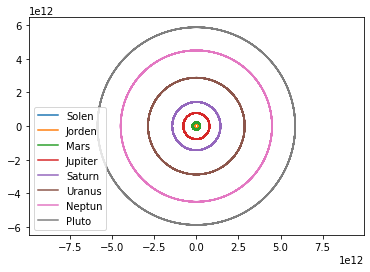

In [2]:
t=np.linspace(0,50000000000,10000)

for i in a:
    def planet_movementx(t):
        return r[i]*np.cos(2*np.pi/T[i]*t+ø[i])
    def planet_movementy(t):
        return r[i]*np.sin(2*np.pi/T[i]*t+ø[i])
    plt.plot(planet_movementx(t),planet_movementy(t),label=planeter_rækkefølge[i])
    plt.axis('equal')
    plt.legend()


# Delopgave a)

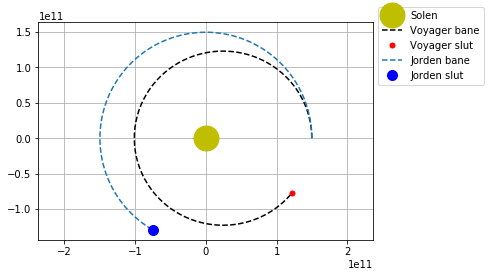

In [3]:
M_sol = M[0]

rx0_jord= r[1]*np.cos((2*np.pi)/(T[1])*0+ø[1])
ry0_jord= r[1]*np.sin((2*np.pi)/(T[1])*0+ø[1])

R_jord=d[1]/2

#Startbetingelser for voyager

rx0_voy = rx0_jord+(1.2*R_jord)
ry0_voy = 0
vx0_voy = -r[1]*(2*np.pi/T[1])*np.sin((2*np.pi/T[1])*0+ø[1])*0.9 #afledte bestemt analytisk
vy0_voy = r[1]*(2*np.pi/T[1])*np.cos((2*np.pi/T[1])*0+ø[1])*0.9

y0 = [rx0_voy, ry0_voy, vx0_voy, vy0_voy] # hjælpevektor

t_span = [0,2/3*365.2*24*60*60]
t_eval = np.linspace(0, 2/3*365.2*24*60*60, 100)

#differentialligning
def dydt(t,y):
    rx=y[0]
    ry=y[1]
    vx=y[2]
    vy=y[3]
    drxdt=vx
    drydt=vy
    d=np.sqrt(rx**2+ry**2)
    dvxdt = -(M_sol*G)/(abs(d**3))*rx
    dvydt = -(M_sol*G)/(abs(d**3))*ry
    return [drxdt, drydt, dvxdt, dvydt]

res = solve_ivp(dydt, t_span, y0, t_eval = t_eval, rtol=10**-9)
#løsning

#plottes

plt.plot(0, 0, 'yo', ms="25",label="Solen")
plt.plot(res.y[0], res.y[1],color="k",linestyle="--", label="Voyager bane") #bane voyager
plt.plot(res.y[0][-1], res.y[1][-1],"ro",ms=5,label="Voyager slut") #slutposition


def jordenx(t):
    return r[1]*np.cos(2*np.pi/T[1]*t+ø[1])
def jordeny(t):
    return r[1]*np.sin(2*np.pi/T[1]*t+ø[1])

plt.plot(jordenx(t_eval),jordeny(t_eval),label="Jorden bane",linestyle="--")
plt.plot(jordenx(t_eval)[-1],jordeny(t_eval)[-1],"bo", ms=10,label="Jorden slut")

plt.axis("equal")
plt.legend(bbox_to_anchor=(1,0.69),loc="lower left",ncol=1)
plt.grid()

# Samme hastighed tjek

Det stemmer!


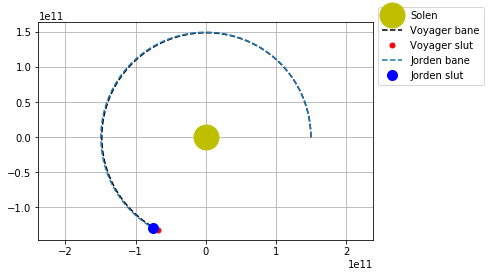

In [4]:
#copy pasted, ændret 0.9 til 1
M_sol = M[0]

rx0_jord= r[1]*np.cos((2*np.pi)/(T[1])*0+ø[1])
ry0_jord= r[1]*np.sin((2*np.pi)/(T[1])*0+ø[1])

R_jord=d[1]/2

#Startbetingelser for voyager

rx0_voy = rx0_jord+(1.2*R_jord)
ry0_voy = 0
vx0_voy = -r[1]*(2*np.pi/T[1])*np.sin((2*np.pi/T[1])*0+ø[1])*1 #afledte bestemt analytisk
vy0_voy = r[1]*(2*np.pi/T[1])*np.cos((2*np.pi/T[1])*0+ø[1])*1

y0 = [rx0_voy, ry0_voy, vx0_voy, vy0_voy] # hjælpevektor

t_span = [0,2/3*365.2*24*60*60]
t_eval = np.linspace(0, 2/3*365.2*24*60*60, 100)

#differentialligning
def dydt(t,y):
    rx=y[0]
    ry=y[1]
    vx=y[2]
    vy=y[3]
    drxdt=vx
    drydt=vy
    d=np.sqrt(rx**2+ry**2)
    dvxdt = -(M_sol*G)/(abs(d**3))*rx
    dvydt = -(M_sol*G)/(abs(d**3))*ry
    return [drxdt, drydt, dvxdt, dvydt]

res = solve_ivp(dydt, t_span, y0, t_eval = t_eval, rtol=10**-9)
#løsning

#plottes

plt.plot(0, 0, 'yo', ms="25",label="Solen")
plt.plot(res.y[0], res.y[1],color="k",linestyle="--", label="Voyager bane") #bane voyager
plt.plot(res.y[0][-1], res.y[1][-1],"ro",ms=5,label="Voyager slut") #slutposition


def jordenx(t):
    return r[1]*np.cos(2*np.pi/T[1]*t+ø[1])
def jordeny(t):
    return r[1]*np.sin(2*np.pi/T[1]*t+ø[1])

plt.plot(jordenx(t_eval),jordeny(t_eval),label="Jorden bane",linestyle="--")
plt.plot(jordenx(t_eval)[-1],jordeny(t_eval)[-1],"bo", ms=10,label="Jorden slut")

plt.axis("equal")
plt.legend(bbox_to_anchor=(1,0.69),loc="lower left",ncol=1)
plt.grid()

print("Det stemmer!")

# Deloopgave b)

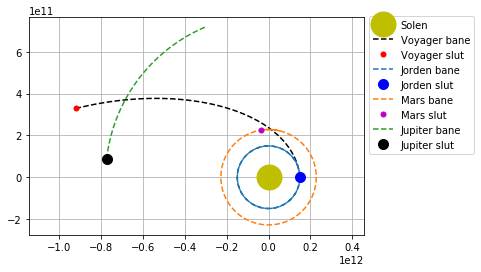

In [5]:
M_sol = M[0]
M_jord = M[1]

rx0_jord= r[1]*np.cos((2*np.pi)/(T[1])*0+ø[1])
ry0_jord= r[1]*np.sin((2*np.pi)/(T[1])*0+ø[1])

R_jord=d[1]/2

#Startbetingelser for voyager

rx0_voy = rx0_jord+(1.2*R_jord)
ry0_voy = 0
vx0_voy = (-r[1]*(2*np.pi/T[1])*np.sin((2*np.pi/T[1])*0+ø[1])) #afledte bestemt analytisk
vy0_voy = (r[1]*(2*np.pi/T[1])*np.cos((2*np.pi/T[1])*0+ø[1]))+15000

y0 = [rx0_voy, ry0_voy, vx0_voy, vy0_voy] # hjælpevektor

t_span = [0,2*365.2*24*60*60]
t_eval = np.linspace(0, 2*365.2*24*60*60, 100)

#differentialligning
def dydt(t,y):
    rx=y[0]
    ry=y[1]
    vx=y[2]
    vy=y[3]
    drxdt=vx
    drydt=vy
    rxjord=r[1]*np.cos(2*np.pi/T[1]*t+ø[1])
    ryjord=r[1]*np.sin(2*np.pi/T[1]*t+ø[1])
    d=np.sqrt(rx**2+ry**2)
    d_jord=np.sqrt((rx-rxjord)**2+(ry-ryjord)**2)
    dvxdt = -(M_sol*G)/(abs(d**3))*rx+(-M_jord*G)/(abs(d_jord**3))*(rx-rxjord)
    dvydt = -(M_sol*G)/(abs(d**3))*ry+(-M_jord*G)/(abs(d_jord**3))*(ry-ryjord)
    return [drxdt, drydt, dvxdt, dvydt]

res = solve_ivp(dydt, t_span, y0, t_eval = t_eval, rtol=10**-9)
#løsning

#plottes

plt.plot(0, 0, 'yo', ms="25",label="Solen")
plt.plot(res.y[0], res.y[1],color="k",linestyle="--", label="Voyager bane") #bane voyager
plt.plot(res.y[0][-1], res.y[1][-1],"ro",ms=5,label="Voyager slut") #slutposition


def jordenx(t):
    return r[1]*np.cos(2*np.pi/T[1]*t+ø[1])
def jordeny(t):
    return r[1]*np.sin(2*np.pi/T[1]*t+ø[1])

plt.plot(jordenx(t_eval),jordeny(t_eval),label="Jorden bane",linestyle="--")
plt.plot(jordenx(t_eval)[-1],jordeny(t_eval)[-1],"bo", ms=10,label="Jorden slut")

#Jupiter og mars for show, ikke en del af tyngdekraftsberegninger
def marsx(t):
    return r[2]*np.cos(2*np.pi/T[2]*t+ø[2])
def marsy(t):
    return r[2]*np.sin(2*np.pi/T[2]*t+ø[2])

plt.plot(marsx(t_eval),marsy(t_eval),label="Mars bane",linestyle="--")
plt.plot(marsx(t_eval)[-1],marsy(t_eval)[-1],"mo", ms=5,label="Mars slut")

def jupiterx(t):
    return r[3]*np.cos(2*np.pi/T[3]*t+ø[3])
def jupitery(t):
    return r[3]*np.sin(2*np.pi/T[3]*t+ø[3])

plt.plot(jupiterx(t_eval),jupitery(t_eval),label="Jupiter bane",linestyle="--")
plt.plot(jupiterx(t_eval)[-1],jupitery(t_eval)[-1],"ko", ms=10,label="Jupiter slut")


plt.axis("equal")
plt.legend(bbox_to_anchor=(1,0.35),loc="lower left",ncol=1)
plt.grid()

# Delopgave c)

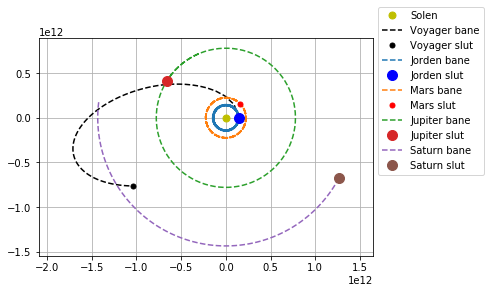

In [6]:
M_sol = M[0]
M_jord = M[1]
M_mars = M[2]
M_jupiter = M[3]
M_saturn = M[4]
M_uranus = M[5]
M_neptun = M[6]
M_pluto = M[7]

rx0_jord= r[1]*np.cos((2*np.pi)/(T[1])*0+ø[1])
ry0_jord= r[1]*np.sin((2*np.pi)/(T[1])*0+ø[1])

R_jord=d[1]/2

#Startbetingelser for voyager

rx0_voy = rx0_jord+(1.2*R_jord)
ry0_voy = 0
vx0_voy = (-r[1]*(2*np.pi/T[1])*np.sin((2*np.pi/T[1])*0+ø[1])) #afledte bestemt analytisk
vy0_voy = (r[1]*(2*np.pi/T[1])*np.cos((2*np.pi/T[1])*0+ø[1]))+15000

y0 = [rx0_voy, ry0_voy, vx0_voy, vy0_voy] # hjælpevektor

t_span = [0,13*365.2*24*60*60]
t_eval = np.linspace(0, 13*365.2*24*60*60, 100)

#differentialligning
def dydt(t,y):
    rx=y[0]
    ry=y[1]
    vx=y[2]
    vy=y[3]
    drxdt=vx
    drydt=vy
    rxjord=r[1]*np.cos(2*np.pi/T[1]*t+ø[1])
    ryjord=r[1]*np.sin(2*np.pi/T[1]*t+ø[1])
    rxmars=r[2]*np.cos(2*np.pi/T[2]*t+ø[2])
    rymars=r[2]*np.sin(2*np.pi/T[2]*t+ø[2])
    rxjupiter=r[3]*np.cos(2*np.pi/T[3]*t+ø[3])
    ryjupiter=r[3]*np.sin(2*np.pi/T[3]*t+ø[3])
    rxsaturn=r[4]*np.cos(2*np.pi/T[4]*t+ø[4])
    rysaturn=r[4]*np.sin(2*np.pi/T[4]*t+ø[4])
    rxuranus=r[5]*np.cos(2*np.pi/T[5]*t+ø[5])
    ryuranus=r[5]*np.sin(2*np.pi/T[5]*t+ø[5])
    rxneptun=r[6]*np.cos(2*np.pi/T[6]*t+ø[6])
    ryneptun=r[6]*np.sin(2*np.pi/T[6]*t+ø[6])
    rxpluto=r[7]*np.cos(2*np.pi/T[7]*t+ø[7])
    rypluto=r[7]*np.sin(2*np.pi/T[7]*t+ø[7])
    d=np.sqrt(rx**2+ry**2)
    d_jord=np.sqrt((rx-rxjord)**2+(ry-ryjord)**2)
    d_mars=np.sqrt((rx-rxmars)**2+(ry-rymars)**2)
    d_jupiter=np.sqrt((rx-rxjupiter)**2+(ry-ryjupiter)**2)
    d_saturn=np.sqrt((rx-rxsaturn)**2+(ry-rysaturn)**2)
    d_uranus=np.sqrt((rx-rxuranus)**2+(ry-ryuranus)**2)
    d_neptun=np.sqrt((rx-rxneptun)**2+(ry-ryneptun)**2)
    d_pluto=np.sqrt((rx-rxpluto)**2+(ry-rypluto)**2)
    dvxdt = -(M_sol*G)/(abs(d**3))*rx+(-M_jord*G)/(abs(d_jord**3))*(rx-rxjord)+(-M_mars*G)/(abs(d_mars**3))*(rx-rxmars)+(-M_jupiter*G)/(abs(d_jupiter**3))*(rx-rxjupiter)+(-M_saturn*G)/(abs(d_saturn**3))*(rx-rxsaturn)+(-M_uranus*G)/(abs(d_uranus**3))*(rx-rxuranus)+(-M_neptun*G)/(abs(d_neptun**3))*(rx-rxneptun)+(-M_pluto*G)/(abs(d_pluto**3))*(rx-rxpluto)
    dvydt = -(M_sol*G)/(abs(d**3))*ry+(-M_jord*G)/(abs(d_jord**3))*(ry-ryjord)+(-M_mars*G)/(abs(d_mars**3))*(ry-rymars)+(-M_jupiter*G)/(abs(d_jupiter**3))*(ry-ryjupiter)+(-M_saturn*G)/(abs(d_saturn**3))*(ry-rysaturn)+(-M_uranus*G)/(abs(d_uranus**3))*(ry-ryuranus)+(-M_neptun*G)/(abs(d_neptun**3))*(ry-ryneptun)+(-M_pluto*G)/(abs(d_pluto**3))*(ry-rypluto)
    return [drxdt, drydt, dvxdt, dvydt]

res = solve_ivp(dydt, t_span, y0, t_eval = t_eval, rtol=10**-9)
#løsning

#plottes

plt.plot(0, 0, 'yo', ms="7",label="Solen")
plt.plot(res.y[0], res.y[1],color="k",linestyle="--", label="Voyager bane") #bane voyager
plt.plot(res.y[0][-1], res.y[1][-1],"ko",ms=5,label="Voyager slut") #slutposition


def jordenx(t):
    return r[1]*np.cos(2*np.pi/T[1]*t+ø[1])
def jordeny(t):
    return r[1]*np.sin(2*np.pi/T[1]*t+ø[1])

plt.plot(jordenx(t_eval),jordeny(t_eval),label="Jorden bane",linestyle="--")
plt.plot(jordenx(t_eval)[-1],jordeny(t_eval)[-1],"bo", ms=10,label="Jorden slut")

def marsx(t):
    return r[2]*np.cos(2*np.pi/T[2]*t+ø[2])
def marsy(t):
    return r[2]*np.sin(2*np.pi/T[2]*t+ø[2])

plt.plot(marsx(t_eval),marsy(t_eval),label="Mars bane",linestyle="--")
plt.plot(marsx(t_eval)[-1],marsy(t_eval)[-1],"ro", ms=5,label="Mars slut")

def jupiterx(t):
    return r[3]*np.cos(2*np.pi/T[3]*t+ø[3])
def jupitery(t):
    return r[3]*np.sin(2*np.pi/T[3]*t+ø[3])

plt.plot(jupiterx(t_eval),jupitery(t_eval),label="Jupiter bane",linestyle="--")
plt.plot(jupiterx(t_eval)[-1],jupitery(t_eval)[-1],"o", ms=10,label="Jupiter slut")

def saturnx(t):
    return r[4]*np.cos(2*np.pi/T[4]*t+ø[4])
def saturny(t):
    return r[4]*np.sin(2*np.pi/T[4]*t+ø[4])

plt.plot(saturnx(t_eval),saturny(t_eval),label="Saturn bane",linestyle="--")
plt.plot(saturnx(t_eval)[-1],saturny(t_eval)[-1],"o", ms=10,label="Saturn slut")


plt.axis("equal")
plt.legend(bbox_to_anchor=(1,0.35),loc="lower left",ncol=1)
plt.grid()

# d)

In [35]:
M_sol = M[0]
M_jord = M[1]
M_mars = M[2]
M_jupiter = M[3]
M_saturn = M[4]
M_uranus = M[5]
M_neptun = M[6]
M_pluto = M[7]

rx0_jord= r[1]*np.cos((2*np.pi)/(T[1])*0+ø[1])
ry0_jord= r[1]*np.sin((2*np.pi)/(T[1])*0+ø[1])

R_jord=d[1]/2

#Startbetingelser for voyager

rx0_voy = rx0_jord+(1.2*R_jord)
ry0_voy = 0
vx0_voy = (-r[1]*(2*np.pi/T[1])*np.sin((2*np.pi/T[1])*0+ø[1])) #afledte bestemt analytisk
vy0_voy = (r[1]*(2*np.pi/T[1])*np.cos((2*np.pi/T[1])*0+ø[1]))+15000

y0 = [rx0_voy, ry0_voy, vx0_voy, vy0_voy] # hjælpevektor

t_span = [0,2*365.2*24*60*60]
t_eval = np.linspace(0, 2*365.2*24*60*60, 100)

#differentialligning
def dydt(t,y):
    rx=y[0]
    ry=y[1]
    vx=y[2]
    vy=y[3]
    drxdt=vx
    drydt=vy
    rxjord=r[1]*np.cos(2*np.pi/T[1]*t+ø[1])
    ryjord=r[1]*np.sin(2*np.pi/T[1]*t+ø[1])
    rxmars=r[2]*np.cos(2*np.pi/T[2]*t+ø[2])
    rymars=r[2]*np.sin(2*np.pi/T[2]*t+ø[2])
    rxjupiter=r[3]*np.cos(2*np.pi/T[3]*t+ø[3])
    ryjupiter=r[3]*np.sin(2*np.pi/T[3]*t+ø[3])
    rxsaturn=r[4]*np.cos(2*np.pi/T[4]*t+ø[4])
    rysaturn=r[4]*np.sin(2*np.pi/T[4]*t+ø[4])
    rxuranus=r[5]*np.cos(2*np.pi/T[5]*t+ø[5])
    ryuranus=r[5]*np.sin(2*np.pi/T[5]*t+ø[5])
    rxneptun=r[6]*np.cos(2*np.pi/T[6]*t+ø[6])
    ryneptun=r[6]*np.sin(2*np.pi/T[6]*t+ø[6])
    rxpluto=r[7]*np.cos(2*np.pi/T[7]*t+ø[7])
    rypluto=r[7]*np.sin(2*np.pi/T[7]*t+ø[7])
    d=np.sqrt(rx**2+ry**2)
    d_jord=np.sqrt((rx-rxjord)**2+(ry-ryjord)**2)
    d_mars=np.sqrt((rx-rxmars)**2+(ry-rymars)**2)
    d_jupiter=np.sqrt((rx-rxjupiter)**2+(ry-ryjupiter)**2)
    d_saturn=np.sqrt((rx-rxsaturn)**2+(ry-rysaturn)**2)
    d_uranus=np.sqrt((rx-rxuranus)**2+(ry-ryuranus)**2)
    d_neptun=np.sqrt((rx-rxneptun)**2+(ry-ryneptun)**2)
    d_pluto=np.sqrt((rx-rxpluto)**2+(ry-rypluto)**2)
    dvxdt = -(M_sol*G)/(abs(d**3))*rx+(-M_jord*G)/(abs(d_jord**3))*(rx-rxjord)+(-M_mars*G)/(abs(d_mars**3))*(rx-rxmars)+(-M_jupiter*G)/(abs(d_jupiter**3))*(rx-rxjupiter)+(-M_saturn*G)/(abs(d_saturn**3))*(rx-rxsaturn)+(-M_uranus*G)/(abs(d_uranus**3))*(rx-rxuranus)+(-M_neptun*G)/(abs(d_neptun**3))*(rx-rxneptun)+(-M_pluto*G)/(abs(d_pluto**3))*(rx-rxpluto)
    dvydt = -(M_sol*G)/(abs(d**3))*ry+(-M_jord*G)/(abs(d_jord**3))*(ry-ryjord)+(-M_mars*G)/(abs(d_mars**3))*(ry-rymars)+(-M_jupiter*G)/(abs(d_jupiter**3))*(ry-ryjupiter)+(-M_saturn*G)/(abs(d_saturn**3))*(ry-rysaturn)+(-M_uranus*G)/(abs(d_uranus**3))*(ry-ryuranus)+(-M_neptun*G)/(abs(d_neptun**3))*(ry-ryneptun)+(-M_pluto*G)/(abs(d_pluto**3))*(ry-rypluto)
    return [drxdt, drydt, dvxdt, dvydt]

#eventfunktion
def event(t,y):
    rx=y[0]
    ry=y[1]
    vx=y[2]
    vy=y[3]
    drxdt=vx
    drydt=vy
    rxjupiter=r[3]*np.cos(2*np.pi/T[3]*t+ø[3])
    ryjupiter=r[3]*np.sin(2*np.pi/T[3]*t+ø[3])
#     d=np.sqrt(rx**2+ry**2)
#     d_jupiter=np.sqrt((rx-rxjupiter)**2+(ry-ryjupiter)**2)
    rvoy=np.array([rx,ry])
    rjupiter=np.array([rxjupiter, ryjupiter])
    
    p=rjupiter-rvoy
#     p = d-d_jupiter
    return p-(1*142984*1000)
event.terminal = True

res = solve_ivp(dydt, t_span, y0, events=[event],t_eval = t_eval, rtol=10**-9)
#løsning

#plottes

plt.plot(0, 0, 'yo', ms="7",label="Solen")
plt.plot(res.y[0], res.y[1],color="k",linestyle="--", label="Voyager bane") #bane voyager
plt.plot(res.y[0][-1], res.y[1][-1],"ko",ms=5,label="Voyager slut") #slutposition


def jordenx(t):
    return r[1]*np.cos(2*np.pi/T[1]*t+ø[1])
def jordeny(t):
    return r[1]*np.sin(2*np.pi/T[1]*t+ø[1])

plt.plot(jordenx(t_eval),jordeny(t_eval),label="Jorden bane",linestyle="--")
plt.plot(jordenx(t_eval)[-1],jordeny(t_eval)[-1],"bo", ms=10,label="Jorden slut")

def marsx(t):
    return r[2]*np.cos(2*np.pi/T[2]*t+ø[2])
def marsy(t):
    return r[2]*np.sin(2*np.pi/T[2]*t+ø[2])

plt.plot(marsx(t_eval),marsy(t_eval),label="Mars bane",linestyle="--")
plt.plot(marsx(t_eval)[-1],marsy(t_eval)[-1],"ro", ms=5,label="Mars slut")

def jupiterx(t):
    return r[3]*np.cos(2*np.pi/T[3]*t+ø[3])
def jupitery(t):
    return r[3]*np.sin(2*np.pi/T[3]*t+ø[3])

plt.plot(jupiterx(t_eval),jupitery(t_eval),label="Jupiter bane",linestyle="--")
plt.plot(jupiterx(t_eval)[-1],jupitery(t_eval)[-1],"o", ms=10,label="Jupiter slut")

def saturnx(t):
    return r[4]*np.cos(2*np.pi/T[4]*t+ø[4])
def saturny(t):
    return r[4]*np.sin(2*np.pi/T[4]*t+ø[4])

#plt.plot(saturnx(t_eval),saturny(t_eval),label="Saturn bane",linestyle="--")
#plt.plot(saturnx(t_eval)[-1],saturny(t_eval)[-1],"o", ms=10,label="Saturn slut")


plt.axis("equal")
plt.legend(bbox_to_anchor=(1,0.35),loc="lower left",ncol=1)
plt.grid()

TypeError: only size-1 arrays can be converted to Python scalars

# e)

In [30]:
M_sol = M[0]
M_jord = M[1]
M_mars = M[2]
M_jupiter = M[3]
M_saturn = M[4]
M_uranus = M[5]
M_neptun = M[6]
M_pluto = M[7]

# rx0_jord= r[1]*np.cos((2*np.pi)/(T[1])*0+ø[1])
# ry0_jord= r[1]*np.sin((2*np.pi)/(T[1])*0+ø[1])

R_jord=d[1]/2

#Startbetingelser for voyager

# rx0_voy = rx0_jord+(1.2*R_jord)
# ry0_voy = 0
# vx0_voy = (-r[1]*(2*np.pi/T[1])*np.sin((2*np.pi/T[1])*0+ø[1])) #afledte bestemt analytisk
# vy0_voy = (r[1]*(2*np.pi/T[1])*np.cos((2*np.pi/T[1])*0+ø[1]))+15000

# y0 = [rx0_voy, ry0_voy, vx0_voy, vy0_voy] # hjælpevektor

ggx = (r[1]*np.cos((2*np.pi)/(T[1])*0+ø[1])+(1.2*R_jord))-r[3]*np.cos(2*np.pi/T[3]*0+ø[3])
ggy = r[1]*np.sin((2*np.pi)/(T[1])*0+ø[1])-r[3]*np.sin(2*np.pi/T[3]*0+ø[3])

y0 = [ggx, ggy]


t_span = [0,13*365.2*24*60*60]
t_eval = np.linspace(0, 13*365.2*24*60*60, 100)

#Jupiter Placering
#rxjupiter=r[3]*np.cos(2*np.pi/T[3]*t+ø[3])
#ryjupiter=r[3]*np.sin(2*np.pi/T[3]*t+ø[3])

#hastighedsvektorer jupiter
#drxjupiterdt = -r[3]*np.sin(2*np.pi/T[3]*t+ø[3])*(2*np.pi/T[3])
#dryjupiterdt = r[3]*np.cos(2*np.pi/T[3]*t+ø[3])*(2*np.pi/T[3])
    
#     d = np.sqrt(rx**2+ry**2)
#     dv = np.sqrt(vx**2+vy**2)
    
#     d_jupiter = np.sqrt((rx-rxjupiter)**2+(ry-ryjupiter)**2)
#     dv_jupiter = np.sqrt((vx-drxjupiterdt)**2+(vy-dryjupiterdt)**2)
    
#     rtilde = d-d_jupiter
#     vtilde = dv-dv_jupiter
#     vII = (vtilde*rtilde)/(rtilde**2)*rtilde



#differentialligning
def dydt(t,y):
    rx=y[0]
    ry=y[1]
    vx=y[2]
    vy=y[3]
    drxdt=vx
    drydt=vy
    
#     rxjord=r[1]*np.cos(2*np.pi/T[1]*t+ø[1])
#     ryjord=r[1]*np.sin(2*np.pi/T[1]*t+ø[1])
    
#     rxmars=r[2]*np.cos(2*np.pi/T[2]*t+ø[2])
#     rymars=r[2]*np.sin(2*np.pi/T[2]*t+ø[2])
    
    rxjupiter=r[3]*np.cos(2*np.pi/T[3]*t+ø[3])
    ryjupiter=r[3]*np.sin(2*np.pi/T[3]*t+ø[3])
    drxjupiterdt = -r[3]*np.sin(2*np.pi/T[3]*t+ø[3])*(2*np.pi/T[3])
    dryjupiterdt = r[3]*np.cos(2*np.pi/T[3]*t+ø[3])*(2*np.pi/T[3])
    
#     rxsaturn=r[4]*np.cos(2*np.pi/T[4]*t+ø[4])
#     rysaturn=r[4]*np.sin(2*np.pi/T[4]*t+ø[4])
    
#     rxuranus=r[5]*np.cos(2*np.pi/T[5]*t+ø[5])
#     ryuranus=r[5]*np.sin(2*np.pi/T[5]*t+ø[5])
    
#     rxneptun=r[6]*np.cos(2*np.pi/T[6]*t+ø[6])
#     ryneptun=r[6]*np.sin(2*np.pi/T[6]*t+ø[6])
    
#     rxpluto=r[7]*np.cos(2*np.pi/T[7]*t+ø[7])
#     rypluto=r[7]*np.sin(2*np.pi/T[7]*t+ø[7])
    
#     d=np.sqrt(rx**2+ry**2)
#     d_jord=np.sqrt((rx-rxjord)**2+(ry-ryjord)**2)
#     d_mars=np.sqrt((rx-rxmars)**2+(ry-rymars)**2)
#     d_jupiter=np.sqrt((rx-rxjupiter)**2+(ry-ryjupiter)**2)
#     dv_jupiter=np.sqrt((vx-drxjupiterdt)**2+(vy-dryjupiterdt)**2)
    
#     d_saturn=np.sqrt((rx-rxsaturn)**2+(ry-rysaturn)**2)
#     d_uranus=np.sqrt((rx-rxuranus)**2+(ry-ryuranus)**2)
#     d_neptun=np.sqrt((rx-rxneptun)**2+(ry-ryneptun)**2)
#     d_pluto=np.sqrt((rx-rxpluto)**2+(ry-rypluto)**2)
    
    rxtilde = rx-rxjupiter
    rytilde = ry-ryjupiter
    vxtilde = drxdt-drxjupiterdt
    vytilde = drydt-dryjupiterdt
    
#     dvxdt = -(M_sol*G)/(abs(d**3))*rx+(-M_jord*G)/(abs(d_jord**3))*(rx-rxjord)+(-M_mars*G)/(abs(d_mars**3))*(rx-rxmars)+(-M_jupiter*G)/(abs(d_jupiter**3))*(rx-rxjupiter)+(-M_saturn*G)/(abs(d_saturn**3))*(rx-rxsaturn)+(-M_uranus*G)/(abs(d_uranus**3))*(rx-rxuranus)+(-M_neptun*G)/(abs(d_neptun**3))*(rx-rxneptun)+(-M_pluto*G)/(abs(d_pluto**3))*(rx-rxpluto)
#     dvydt = -(M_sol*G)/(abs(d**3))*ry+(-M_jord*G)/(abs(d_jord**3))*(ry-ryjord)+(-M_mars*G)/(abs(d_mars**3))*(ry-rymars)+(-M_jupiter*G)/(abs(d_jupiter**3))*(ry-ryjupiter)+(-M_saturn*G)/(abs(d_saturn**3))*(ry-rysaturn)+(-M_uranus*G)/(abs(d_uranus**3))*(ry-ryuranus)+(-M_neptun*G)/(abs(d_neptun**3))*(ry-ryneptun)+(-M_pluto*G)/(abs(d_pluto**3))*(ry-rypluto)
    return [rxtilde, rytilde, vxtilde, vytilde]
#     return [drxdt, drydt, dvxdt, dvydt]

#eventfunktion
# def event(t,y):
#     rx=y[0]
#     ry=y[1]
#     vx=y[2]
#     vy=y[3]
#     drxdt=vx
#     drydt=vy
#     rxjupiter=r[3]*np.cos(2*np.pi/T[3]*t+ø[3])
#     ryjupiter=r[3]*np.sin(2*np.pi/T[3]*t+ø[3])
    
#     drxjupiterdt = -r[3]*np.sin(2*np.pi/T[3]*t+ø[3])*(2*np.pi/T[3])
#     dryjupiterdt = r[3]*np.cos(2*np.pi/T[3]*t+ø[3])*(2*np.pi/T[3])
    
#     d = np.sqrt(rx**2+ry**2)
#     dv = np.sqrt(vx**2+vy**2)
    
#     d_jupiter = np.sqrt((rx-rxjupiter)**2+(ry-ryjupiter)**2)
#     dv_jupiter = np.sqrt((vx-drxjupiterdt)**2+(vy-dryjupiterdt)**2)
    
#     rtilde = d-d_jupiter
#     vtilde = dv-dv_jupiter
#     vII = (vtilde*rtilde)/(rtilde**2)*rtilde
    
#     return 
# event.terminal = True
# events=[event],

res = solve_ivp(dydt, t_span, y0, t_eval = t_eval, rtol=10**-9)
#løsning

#plottes

plt.plot(0, 0, 'yo', ms="7",label="Jupiter")
plt.plot(res.y[0], res.y[1],color="k",linestyle="--", label="Voyager bane") #bane voyager
plt.plot(res.y[0][-1], res.y[1][-1],"ko",ms=5,label="Voyager slut") #slutposition



plt.axis("equal")
plt.legend(bbox_to_anchor=(1,0.35),loc="lower left",ncol=1)
plt.grid()

IndexError: index 2 is out of bounds for axis 0 with size 2